In [ ]:
#@title Download model from roboflow

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-detection-28o0o")
version = project.version(1)
dataset = version.download("sam2")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 122.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PV-detection--1 in sam2:: 100%|██████████| 41/41 [00:00<00:00, 5546.95it/s]


  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (49.9 MB)
loading Roboflow workspace...
loading Roboflow project...


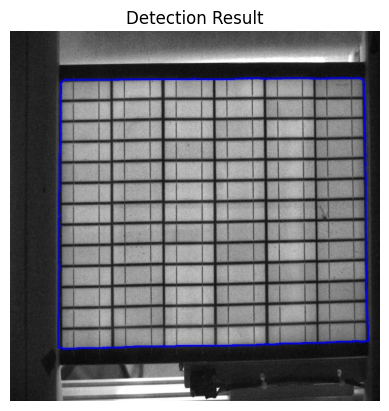

In [ ]:
#@title Show the model result

!pip install roboflow


from roboflow import Roboflow
import cv2
from matplotlib import pyplot as plt


rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-detection-28o0o")
version = project.version(1)
model = version.model

image_path = "/content/D210AABB3B20180004_png.rf.1c2cfcbd638881a13da4432a71355c7f.jpg"  # ← ← ← حطي هنا مسار الصورة
result = model.predict(image_path, confidence=40).save("result.jpg")

img = cv2.imread("result.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.title("Detection Result")
plt.show()


loading Roboflow workspace...
loading Roboflow project...


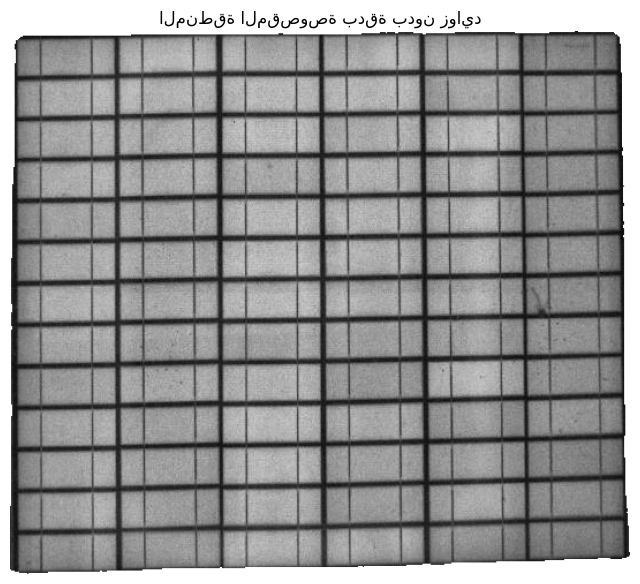

In [ ]:
#@title used polygons in cutting
from roboflow import Roboflow
import cv2
import numpy as np
from matplotlib import pyplot as plt


rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-detection-28o0o")
version = project.version(1)
model = version.model

image_path = "/content/D210AABB3B20180004_png.rf.1c2cfcbd638881a13da4432a71355c7f.jpg"
img = cv2.imread(image_path)


prediction = model.predict(image_path, confidence=40).json()

pred = prediction["predictions"][0]
points = pred["points"]
polygon = np.array([[int(p["x"]), int(p["y"])] for p in points], dtype=np.int32)

mask = np.zeros(img.shape[:2], dtype=np.uint8)
cv2.fillPoly(mask, [polygon], 255)

result = cv2.bitwise_and(img, img, mask=mask)

x, y, w, h = cv2.boundingRect(polygon)
cropped_polygon = result[y:y+h, x:x+w]
mask_crop = mask[y:y+h, x:x+w]


cropped_polygon[mask_crop == 0] = [255, 255, 255]


plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(cropped_polygon, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("المنطقة المقصوصة بدقة بدون زوايد")
plt.show()


loading Roboflow workspace...
loading Roboflow project...


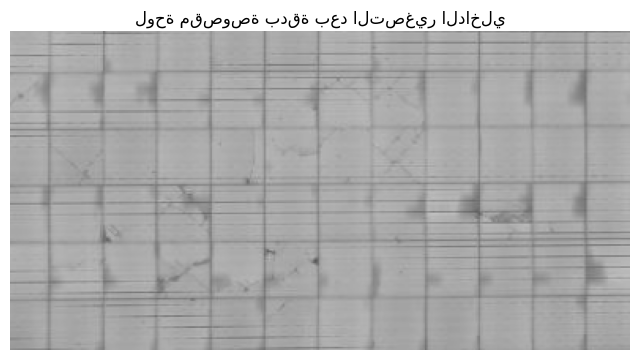

In [ ]:
#@title Final value

from roboflow import Roboflow
import cv2
import numpy as np
from matplotlib import pyplot as plt


rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-detection-28o0o")
version = project.version(1)
model = version.model


image_path = "/content/2_jpg.rf.ae542166c8968619d332ad59e4cf117e.jpg"
img = cv2.imread(image_path)


prediction = model.predict(image_path, confidence=40).json()
pred = prediction["predictions"][0]
points = np.array([[p["x"], p["y"]] for p in pred["points"]], dtype=np.float32)


def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

ordered_pts = order_points(points)


center = np.mean(ordered_pts, axis=0)
shrink_factor = 0.96
shrunken_pts = (ordered_pts - center) * shrink_factor + center


(tl, tr, br, bl) = shrunken_pts
widthA = np.linalg.norm(br - bl)
widthB = np.linalg.norm(tr - tl)
maxWidth = int(max(widthA, widthB))

heightA = np.linalg.norm(tr - br)
heightB = np.linalg.norm(tl - bl)
maxHeight = int(max(heightA, heightB))

dst = np.array([
    [0, 0],
    [maxWidth - 1, 0],
    [maxWidth - 1, maxHeight - 1],
    [0, maxHeight - 1]
], dtype="float32")


M = cv2.getPerspectiveTransform(shrunken_pts, dst)
warped = cv2.warpPerspective(img, M, (maxWidth, maxHeight))


cv2.imwrite("omnia.jpg", warped)


plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("لوحة مقصوصة بدقة بعد التصغير الداخلي")
plt.show()


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-ngad4")
version = project.version(1)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 89.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to PV-1 in coco:: 100%|██████████| 2992/2992 [00:10<00:00, 291.03it/s]


In [ ]:
from roboflow import Roboflow


rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-ngad4")
version = project.version(1)
model = version.model


image_path = "/content/2_jpg.rf.ae542166c8968619d332ad59e4cf117e.jpg"

prediction = model.predict(image_path, confidence=40, overlap=30).json()

model.predict(image_path, confidence=40, overlap=30).save("prediction.jpg")

for pred in prediction['predictions']:
    print(f"Detected: {pred['class']} | Confidence: {pred['confidence']:.2f} | Box: ({pred['x']}, {pred['y']}) w={pred['width']} h={pred['height']}")


loading Roboflow workspace...
loading Roboflow project...
Detected: Microcracks | Confidence: 0.68 | Box: (51.5, 97.5) w=29.0 h=27.0
Detected: Branch Cracks | Confidence: 0.67 | Box: (123.0, 125.0) w=20.0 h=28.0
Detected: Branch Cracks | Confidence: 0.66 | Box: (21.0, 54.0) w=30.0 h=24.0
Detected: Microcracks | Confidence: 0.54 | Box: (181.0, 188.5) w=14.0 h=11.0
Detected: Microcracks | Confidence: 0.53 | Box: (121.5, 164.5) w=31.0 h=15.0
Detected: Isolation Area | Confidence: 0.48 | Box: (242.5, 172.5) w=7.0 h=21.0
Detected: Isolation Area | Confidence: 0.47 | Box: (203.0, 160.0) w=6.0 h=6.0
Detected: Microcracks | Confidence: 0.44 | Box: (257.0, 55.0) w=34.0 h=22.0
Detected: Isolation Area | Confidence: 0.44 | Box: (175.5, 154.5) w=9.0 h=7.0
Detected: Microcracks | Confidence: 0.43 | Box: (189.5, 161.5) w=29.0 h=25.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import zipfile
import os


zip_path = "/content/drive/MyDrive/omnia/PV last version.v2i.yolov8.zip"


extract_dir = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ الملف اتفك في: {extract_dir}")

✅ الملف اتفك في: /content/dataset


In [ ]:
import json
import os


folders = ["train", "valid", "test"]

rename_map = {
    "0 Examined": "examined",
    "examined": "examined",
    "1 ShortCircuitString": "low_cell",
    "2 ShortCircuitCell -LowPowerCell-": "low_cell",
    "low_cell": "low_cell",
    "3 Crack": "crack",
    "crack": "crack",
    "4 MicroCrack": "crack",
    "5 OtherError": "break",
    "break": "break",
    "contamination": "contamination",
    "backsheet_scratch": "backsheet_scratch",
    "black_edge": "black_edge",
    "dark_cell": "dark_cell",
    "defectsc-5XAg-Letters-Letters-defects": "defect",
    "fingerline_error": "fingerline_error",
    "isolated_area": "isolated_area",
    "poor_soldering": "poor_soldering",
    "shunt": "shunt",
    "defect":"crack"
}

def unify_coco_classes(file_path):
    with open(file_path, 'r') as f:
        coco_data = json.load(f)

    id_to_name = {cat["id"]: cat["name"] for cat in coco_data["categories"]}


    new_name_set = set()
    for cat in coco_data["categories"]:
        old_name = cat["name"]
        cat["name"] = rename_map.get(old_name, old_name)
        new_name_set.add(cat["name"])


    new_name_list = sorted(list(new_name_set))
    new_id_map = {name: idx + 1 for idx, name in enumerate(new_name_list)}


    coco_data["categories"] = [
        {"id": new_id_map[name], "name": name, "supercategory": ""} for name in new_name_list
    ]


    for ann in coco_data["annotations"]:
        old_class_name = id_to_name[ann["category_id"]]
        new_class_name = rename_map.get(old_class_name, old_class_name)
        ann["category_id"] = new_id_map[new_class_name]


    with open(file_path, 'w') as f:
        json.dump(coco_data, f)
    print(f"✅ تم تعديل: {file_path}")


for folder in folders:
    coco_path = f"/content/dataset/{folder}/_annotations.coco.json"
    if os.path.exists(coco_path):
        unify_coco_classes(coco_path)
    else:
        print(f"❌ الملف غير موجود: {coco_path}")


✅ تم تعديل: /content/dataset/train/_annotations.coco.json
✅ تم تعديل: /content/dataset/valid/_annotations.coco.json
✅ تم تعديل: /content/dataset/test/_annotations.coco.json


In [ ]:
import yaml

yaml_path = "/content/dataset/data.yaml"
with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml['names']
print("✅ الكلاسات الموجودة:")
for i, name in enumerate(class_names):
    print(f"{i}. {name}")


✅ الكلاسات الموجودة:
0. backsheet_scratch
1. black_edge
2. break
3. contamination
4. crack
5. dark_cell
6. examined
7. fingerline_error
8. isolated_area
9. low_cell
10. poor_soldering
11. shunt


In [ ]:
import json


file_path = "/content/dataset/valid/_annotations.coco.json"


with open(file_path, 'r') as f:
    coco_data = json.load(f)

class_names = [cat['name'] for cat in coco_data['categories']]
print("✅ الكلاسات الموجودة بعد التعديل:")
for i, name in enumerate(class_names, 1):
    print(f"{i}. {name}")


✅ الكلاسات الموجودة بعد التعديل:
1. backsheet_scratch
2. black_edge
3. break
4. contamination
5. crack
6. dark_cell
7. examined
8. fingerline_error
9. isolated_area
10. low_cell
11. poor_soldering
12. shunt


In [ ]:
!zip -r /content/dataset_ready.zip /content/dataset


Streaming output truncated to the last 5000 lines.
  adding: content/dataset/test/D210AABB3A20200221_png.rf.e86b27810744466afbf5b875a751635c.jpg (deflated 1%)
  adding: content/dataset/test/D210AABB3A20210095_png.rf.1e9ed4b19dc01262a6dd13e6f8cf634f.jpg (deflated 1%)
  adding: content/dataset/test/2202-2204-2240-2242-D211AABB3A20200467_png.rf.897ecd9690d3aeb9d951ba0f41704c97.jpg (deflated 1%)
  adding: content/dataset/test/D209AABB3A20200505_png.rf.e34d8ef9253a7081a84127575a174a2e.jpg (deflated 1%)
  adding: content/dataset/test/23_jpg.rf.0887931cc600c98def2627058f101b99.jpg (deflated 9%)
  adding: content/dataset/test/D210AABB3A20210100_png.rf.628e668bf998e9696b3ea81998ed3586.jpg (deflated 1%)
  adding: content/dataset/test/B014_png.rf.533188b3ef64b7e7b602c7c6b99427a8.jpg (deflated 2%)
  adding: content/dataset/test/43image-2-_jpg.rf.18633d56a21e88b2d874804f398b41b7.jpg (deflated 2%)
  adding: content/dataset/test/B026_png.rf.2bd1bd56f1aa8dc3571e99f702fc375e.jpg (deflated 3%)
  adding:

In [ ]:
!pip install ultralytics -U


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import zipfile
import os
zip_path = "/content/drive/MyDrive/PV /PV last version.v2i.yolov8.zip"  # ← غيري الاسم حسب اسم الملف اللي رفعتيه
extract_dir = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✅ الملف اتفك في: {extract_dir}")


✅ الملف اتفك في: /content/dataset


In [ ]:
model = YOLO("yolov8n.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16
)


100%|██████████| 6.25M/6.25M [00:00<00:00, 75.0MB/s]


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True,

100%|██████████| 755k/755k [00:00<00:00, 14.0MB/s]

Overriding model.yaml nc=80 with nc=12

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytic

 22        [15, 18, 21]  1    753652  ultralytics.nn.modules.head.Detect           [12, [64, 128, 256]]          
Model summary: 129 layers, 3,013,188 parameters, 3,013,172 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1370.7±566.8 MB/s, size: 49.9 KB)


...

train: New cache created: /content/dataset/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 868.3±224.6 MB/s, size: 53.8 KB)


val: Scanning /content/dataset/valid/labels... 231 images, 0 backgrounds, 0 corrupt: 100%|██████████| 231/231 [00:00<00:00, 1310.78it/s]

val: New cache created: /content/dataset/valid/labels.cache


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000625, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs/detect/train
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/50         0G      2.286      4.547      1.827        261        640:   4%|▍         | 12/295 [03:19<1:15:42, 16.05s/it]

In [ ]:
model = YOLO("yolov8m.pt")

model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/yolo-training",
    name="v8m-custom"
)


100%|██████████| 49.7M/49.7M [00:00<00:00, 104MB/s] 


Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=v8m-custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrain

100%|██████████| 755k/755k [00:00<00:00, 23.4MB/s]

Overriding model.yaml nc=80 with nc=12

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytic

 18                  -1  2   1846272  ultralytics.nn.modules.block.C2f             [576, 384, 2]                 
 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3782644  ultralytics.nn.modules.head.Detect           [12, [192, 384, 576]]         
Model summary: 169 layers, 25,863,268 parameters, 25,863,252 gradients, 79.1 GFLOPs

Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


...

                   all        231       2805      0.512      0.463      0.462      0.314



50 epochs completed in 2.443 hours.
Optimizer stripped from /content/drive/MyDrive/yolo-training/v8m-custom/weights/last.pt, 52.0MB
Optimizer stripped from /content/drive/MyDrive/yolo-training/v8m-custom/weights/best.pt, 52.0MB

Validating /content/drive/MyDrive/yolo-training/v8m-custom/weights/best.pt...
Ultralytics 8.3.167 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,846,708 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:06<00:00,  2.23it/s]


                   all        231       2805      0.513      0.463      0.462      0.314
     backsheet_scratch          8         11      0.602      0.549      0.639      0.353
            black_edge         23        521      0.796      0.893      0.924      0.692
                 break          7         44      0.624      0.182      0.246      0.122
         contamination         22        631      0.458      0.612      0.569      0.334
                 crack        103        813      0.668      0.454      0.515      0.276
             dark_cell          9         60      0.303      0.383      0.303       0.26
              examined        146        146      0.994          1      0.995      0.995
      fingerline_error         13         18          0          0     0.0362     0.0136
         isolated_area         34        175      0.652      0.297      0.358      0.182
              low_cell         33        235      0.472      0.489      0.455      0.348
        poor_solderin

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c7ed091f350>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,  

In [ ]:
import pandas as pd

top_n = 5
csv_path = "/content/drive/MyDrive/yolo-training/v8m-custom/results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

top_epochs = df.sort_values(by='metrics/mAP50-95(B)', ascending=False).head(top_n)
print(f"🔝 أفضل {top_n} Epochs بناءً على mAP50-95:")
print(top_epochs[['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])


🔝 أفضل 5 Epochs بناءً على mAP50-95:
    epoch  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
49     50               0.51225            0.46317           0.46192   
40     41               0.55494            0.48304           0.46330   
47     48               0.55894            0.44314           0.45734   
48     49               0.49572            0.47107           0.45723   
39     40               0.49133            0.51996           0.46342   

    metrics/mAP50-95(B)  
49              0.31370  
40              0.31335  
47              0.31097  
48              0.31037  
39              0.30999  


In [ ]:
import pandas as pd
csv_path = "/content/drive/MyDrive/yolo-training/v8m-custom/results.csv"
df = pd.read_csv(csv_path)

df.columns = df.columns.str.strip()

best_epoch = df.sort_values(by='metrics/mAP50-95(B)', ascending=False).head(1)


print("🏆 أفضل Epoch من حيث mAP50-95:")
print(best_epoch[['epoch', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)']])


🏆 أفضل Epoch من حيث mAP50-95:
    epoch  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
49     50               0.51225            0.46317           0.46192   

    metrics/mAP50-95(B)  
49               0.3137  



image 1/1 /content/902_907_D211AABB3A20210257_png.rf.0aaa0f4dad15acfabdec40d421836065.jpg: 640x640 6 breaks, 10 cracks, 1 examined, 5 low_cells, 37.1ms
Speed: 2.3ms preprocess, 37.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


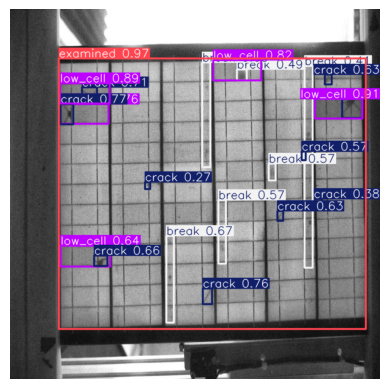

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

model = YOLO("/content/drive/MyDrive/yolo-training/v8m-custom/weights/best.pt")

results = model("/content/902_907_D211AABB3A20210257_png.rf.0aaa0f4dad15acfabdec40d421836065.jpg", conf=0.25)


res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()



image 1/1 /content/D210AABB3A20200228_png.rf.29317c63eaafcb3dca250c65f22f32c7.jpg: 640x640 4 breaks, 1 crack, 1 examined, 3243.2ms
Speed: 4.3ms preprocess, 3243.2ms inference, 10.0ms postprocess per image at shape (1, 3, 640, 640)


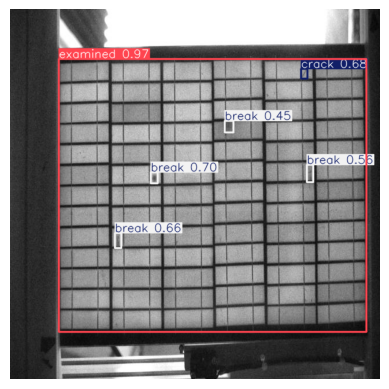

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

model = YOLO("/content/drive/MyDrive/yolo-training/v8m-custom/weights/best.pt")
results = model("/content/D210AABB3A20200228_png.rf.29317c63eaafcb3dca250c65f22f32c7.jpg", conf=0.25)


res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()



image 1/1 /content/2.jpg: 640x576 19 cracks, 7 isolated_areas, 1382.6ms
Speed: 4.3ms preprocess, 1382.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 576)


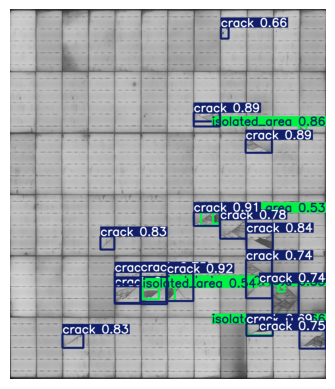

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

model = YOLO("/content/drive/MyDrive/yolo-training/v8m-custom/weights/best.pt")

results = model("/content/2.jpg", conf=0.25)


res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


# **Try to improve the mAP change dataset to only 13 classes**



In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-last-version")
version = project.version(6)
dataset = version.download("coco")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pv-last-version--6 in coco:: 100%|██████████| 4835/4835 [00:08<00:00, 601.89it/s]


In [ ]:
import json
from collections import defaultdict


paths = {
    "train": "/content/pv-last-version--6/train/_annotations.coco.json",
    "valid": "/content/pv-last-version--6/valid/_annotations.coco.json",
    "test": "/content/pv-last-version--6/test/_annotations.coco.json"
}

class_counts = defaultdict(lambda: {"train": 0, "valid": 0, "test": 0})
category_id_to_name = {}

for split, path in paths.items():
    with open(path, 'r') as f:
        data = json.load(f)
        if not category_id_to_name:
            for cat in data["categories"]:
                category_id_to_name[cat["id"]] = cat["name"]


        for ann in data["annotations"]:
            cat_id = ann["category_id"]
            class_counts[category_id_to_name[cat_id]][split] += 1

print("📊 عدد مرات ظهور كل كلاس في train/valid/test:")
print("-" * 60)
print(f"{'Class':<20}{'Train':<10}{'Valid':<10}{'Test':<10}")
print("-" * 60)

for class_name, counts in class_counts.items():
    print(f"{class_name:<20}{counts['train']:<10}{counts['valid']:<10}{counts['test']:<10}")




📊 عدد مرات ظهور كل كلاس في train/valid/test:
------------------------------------------------------------
Class               Train     Valid     Test      
------------------------------------------------------------
crack               1920      475       113       
examined            848       193       61        
5 OtherError        9951      834       1445      
4 MicroCrack        13657     1169      2178      
0 Examined          1689      123       289       
black_edge          965       394       60        
low_cell            1462      308       32        
1 ShortCircuitString624       38        80        
Partially Dark      528       91        49        
Poor Ribbon Soldering931       140       73        
Micro crack         746       69        63        
Shunt               1209      133       144       
2 ShortCircuitCell -LowPowerCell-1450      124       207       
3 Crack             641       41        118       
Branch Cracks       1305      128       144       
Iso

In [ ]:
# كل كلاس هيتحوّل للكلاس الجديد التالي:
MERGE_MAP = {
    'crack': 'crack',
    'Crack': 'crack',
    '3 Crack': 'crack',
    'Branch Cracks': 'crack',
    'Branch crack': 'crack',


    'MicroCrack': 'microcrack',
    '4 MicroCrack': 'microcrack',
    'Micro crack': 'microcrack',
    'Microcracks': 'microcrack',


    'examined': 'examined',
    '0 Examined': 'examined',
    'Examined': 'examined',

    'black_edge': 'black_edge',
    'black_cell': 'dark_cell',


    'low_cell': 'low_cell',


    'Dark Cell': 'dark_cell',
    'DarkSpot': 'dark_cell',

    '1 ShortCircuitString': 'dark_cell',
    '2 ShortCircuitCell -LowPowerCell-': 'short_circuit',

    'Partially Dark': 'partially_dark',

    'Poor Ribbon Soldering': 'poor_ribbon_soldering',

    'Shunt': 'other_error',

    'Isolation Area': 'isolation_area',
    'Isolated area': 'isolation_area',

    'Fingerline Interruption': 'fingerline_interruption',

    'Backsheet Scratch': 'other_error',
    'Scratch': 'other_error',

    'contamination': 'contamination',
    'Contamination': 'contamination',



    '5 OtherError': 'other_error',
    'break': 'other_error',
}


NEW_CLASSES = sorted(set(MERGE_MAP.values()))
NEW_CLASS_ID = {name: i for i, name in enumerate(NEW_CLASSES)}

def remap_coco_file(input_path, output_path):
    with open(input_path, 'r') as f:
        data = json.load(f)

    old_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}

    new_categories = [{"id": NEW_CLASS_ID[name], "name": name} for name in NEW_CLASSES]


    new_annotations = []
    for ann in data['annotations']:
        old_cat_name = old_id_to_name[ann['category_id']]
        merged_name = MERGE_MAP.get(old_cat_name)

        if merged_name is None:
            continue

        ann['category_id'] = NEW_CLASS_ID[merged_name]
        new_annotations.append(ann)

    data['annotations'] = new_annotations
    data['categories'] = new_categories

    with open(output_path, 'w') as f:
        json.dump(data, f)

remap_coco_file("/content/pv-last-version--6/train/_annotations.coco.json", "/content/pv-last-version--6/train/_remapped.coco.json")
remap_coco_file("/content/pv-last-version--6/valid/_annotations.coco.json", "/content/pv-last-version--6/valid/_remapped.coco.json")
remap_coco_file("/content/pv-last-version--6/test/_annotations.coco.json", "/content/pv-last-version--6/test/_remapped.coco.json")

print("New classes with their new IDs:")
for name, class_id in NEW_CLASS_ID.items():
    print(f"{class_id}: {name}")


New classes with their new IDs:
0: black_edge
1: contamination
2: crack
3: dark_cell
4: examined
5: fingerline_interruption
6: isolation_area
7: low_cell
8: microcrack
9: other_error
10: partially_dark
11: poor_ribbon_soldering
12: short_circuit


In [ ]:
import json
from collections import defaultdict

# المسارات
paths = {
    "train": "/content/pv-last-version--6/train/_remapped.coco.json",
    "valid": "/content/pv-last-version--6/valid/_remapped.coco.json",
    "test": "/content/pv-last-version--6/test/_remapped.coco.json",
}


class_counts = defaultdict(lambda: {"train": 0, "valid": 0, "test": 0})
category_id_to_name = {}


for path in paths.values():
    with open(path, 'r') as f:
        data = json.load(f)
        for cat in data["categories"]:
            category_id_to_name[cat["id"]] = cat["name"]

for split, path in paths.items():
    with open(path, 'r') as f:
        data = json.load(f)

        for ann in data["annotations"]:
            cat_id = ann["category_id"]
            class_name = category_id_to_name.get(cat_id, f"Unknown({cat_id})")
            class_counts[class_name][split] += 1

# طباعة النتائج
print("📊 عدد مرات ظهور كل كلاس في train/valid/test:")
print("-" * 60)
print(f"{'Class':<20}{'Train':<10}{'Valid':<10}{'Test':<10}")
print("-" * 60)

for class_name, counts in class_counts.items():
    print(f"{class_name:<20}{counts['train']:<10}{counts['valid']:<10}{counts['test']:<10}")


📊 عدد مرات ظهور كل كلاس في train/valid/test:
------------------------------------------------------------
Class               Train     Valid     Test      
------------------------------------------------------------
crack               4167      652       418       
examined            2543      317       350       
other_error         11658     1036      1608      
microcrack          17777     1793      2605      
black_edge          965       394       60        
low_cell            1462      308       32        
dark_cell           887       346       85        
partially_dark      528       91        49        
poor_ribbon_soldering931       140       73        
short_circuit       1450      124       207       
isolation_area      2699      335       205       
fingerline_interruption239       32        26        
contamination       5953      800       219       


In [ ]:
import json

def print_classes_from_file(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    print("✅ Classes in file after remapping:")
    for cat in data['categories']:
        print(f"{cat['id']}: {cat['name']}")

print_classes_from_file("/content/pv-last-version--6/train/_remapped.coco.json")


✅ Classes in file after remapping:
0: black_edge
1: contamination
2: crack
3: dark_cell
4: examined
5: fingerline_interruption
6: isolation_area
7: low_cell
8: microcrack
9: other_error
10: partially_dark
11: poor_ribbon_soldering
12: short_circuit


In [ ]:
import shutil

dataset_folder = "/content/pv-last-version--6"

output_zip = "/content/pv-last-version--6(with change to 13 classes).zip"


shutil.make_archive(output_zip.replace(".zip", ""), 'zip', dataset_folder)

print("✅ تم ضغط الداتا بنجاح! الملف موجود في:", output_zip)


✅ تم ضغط الداتا بنجاح! الملف موجود في: /content/pv-last-version--6(with change to 13 classes).zip


# **another try to use less classes**

In [ ]:

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yRDvptJ8KLwC6skubCmN")
project = rf.workspace("omnia-yvh6d").project("pv-last-version")
version = project.version(9)
dataset = version.download("coco")



loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import json
from collections import defaultdict


paths = {
    "train": "/content/pv-last-version--9/train/_annotations.coco.json",
    "valid": "/content/pv-last-version--9/valid/_annotations.coco.json",
    "test": "/content/pv-last-version--9/test/_annotations.coco.json"
}


class_counts = defaultdict(lambda: {"train": 0, "valid": 0, "test": 0})
category_id_to_name = {}


for split, path in paths.items():
    with open(path, 'r') as f:
        data = json.load(f)

        if not category_id_to_name:
            for cat in data["categories"]:
                category_id_to_name[cat["id"]] = cat["name"]


        for ann in data["annotations"]:
            cat_id = ann["category_id"]
            class_counts[category_id_to_name[cat_id]][split] += 1


print("📊 عدد مرات ظهور كل كلاس في train/valid/test:")
print("-" * 60)
print(f"{'Class':<20}{'Train':<10}{'Valid':<10}{'Test':<10}")
print("-" * 60)

for class_name, counts in class_counts.items():
    print(f"{class_name:<20}{counts['train']:<10}{counts['valid']:<10}{counts['test']:<10}")




📊 عدد مرات ظهور كل كلاس في train/valid/test:
------------------------------------------------------------
Class               Train     Valid     Test      
------------------------------------------------------------
Micro crack         308       22        27        
Shunt               563       30        84        
Backsheet Scratch   87        5         4         
Isolation Area      616       139       49        
Microcracks         1365      188       109       
examined            293       53        20        
low_cell            581       51        44        
Branch Cracks       512       41        22        
0 Examined          607       30        59        
4 MicroCrack        5772      217       313       
5 OtherError        3855      215       240       
3 Crack             146       8         16        
2 ShortCircuitCell -LowPowerCell-329       34        71        
contamination       2209      137       184       
Fingerline Interruption104       3         14        
c

In [ ]:

MERGE_MAP = {
    'crack': 'crack',
    'Crack': 'crack',
    '3 Crack': 'crack',
    'Branch Cracks': 'crack',
    'Branch crack': 'crack',


    'MicroCrack': 'microcrack',
    '4 MicroCrack': 'microcrack',
    'Micro crack': 'microcrack',
    'Microcracks': 'microcrack',


    'examined': 'examined',
    '0 Examined': 'examined',
    'Examined': 'examined',

    'black_edge': 'low_cell',
    'black_cell': 'low_cell',


    'low_cell': 'low_cell',


    'Dark Cell': 'low_cell',
    'DarkSpot': 'low_cell',

    '1 ShortCircuitString': 'low_cell',
    '2 ShortCircuitCell -LowPowerCell-': 'short_circuit',

    'Partially Dark': 'low_cell',

    'Poor Ribbon Soldering': 'poor_ribbon_soldering',

    'Shunt': 'other_error',

    'Isolation Area': 'isolation_area',
    'Isolated area': 'isolation_area',

    'Fingerline Interruption': 'fingerline_interruption',

    'Backsheet Scratch': 'other_error',
    'Scratch': 'other_error',

    'contamination': 'contamination',
    'Contamination': 'contamination',



    '5 OtherError': 'other_error',
    'break': 'other_error',
}


NEW_CLASSES = sorted(set(MERGE_MAP.values()))
NEW_CLASS_ID = {name: i for i, name in enumerate(NEW_CLASSES)}

def remap_coco_file(input_path, output_path):
    with open(input_path, 'r') as f:
        data = json.load(f)

    # Map old category id -> name
    old_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}

    new_categories = [{"id": NEW_CLASS_ID[name], "name": name} for name in NEW_CLASSES]

    new_annotations = []
    for ann in data['annotations']:
        old_cat_name = old_id_to_name[ann['category_id']]
        merged_name = MERGE_MAP.get(old_cat_name)

        if merged_name is None:
            continue

        ann['category_id'] = NEW_CLASS_ID[merged_name]
        new_annotations.append(ann)

    data['annotations'] = new_annotations
    data['categories'] = new_categories

    with open(output_path, 'w') as f:
        json.dump(data, f)

remap_coco_file("/content/pv-last-version--9/train/_annotations.coco.json", "/content/pv-last-version--9/train/_remapped.coco.json")
remap_coco_file("/content/pv-last-version--9/valid/_annotations.coco.json", "/content/pv-last-version--9/valid/_remapped.coco.json")
remap_coco_file("/content/pv-last-version--9/test/_annotations.coco.json", "/content/pv-last-version--9/test/_remapped.coco.json")

print("New classes with their new IDs:")
for name, class_id in NEW_CLASS_ID.items():
    print(f"{class_id}: {name}")


New classes with their new IDs:
0: contamination
1: crack
2: examined
3: fingerline_interruption
4: isolation_area
5: low_cell
6: microcrack
7: other_error
8: poor_ribbon_soldering
9: short_circuit


In [ ]:
import shutil

dataset_folder = "/content/pv-last-version--9"

output_zip = "/content/pv-last-version--9(with change to 10 classes).zip"

shutil.make_archive(output_zip.replace(".zip", ""), 'zip', dataset_folder)

print("✅ تم ضغط الداتا بنجاح! الملف موجود في:", output_zip)


✅ تم ضغط الداتا بنجاح! الملف موجود في: /content/pv-last-version--9(with change to 10 classes).zip


# **Training**

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="I9vohnBPTTnfP90JG5ML")
project = rf.workspace("omnia-lp9xt").project("pv-last-version-6cpma")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 47.8 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to pv-last-version-بجد-بقيييي-3 in yolov8:: 100%|██████████| 5514/5514 [00:00<00:00, 6518.88it/s]


In [ ]:
!pip install ultralytics -U


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8m.pt")

model.train(
    data="/content/pv-last-version-بجد-بقيييي-3/data.yaml",
    epochs=100,
    imgsz=640,
    batch=8,
    project="/content/drive/MyDrive/yolo-last-version",
    name="v8m-custom"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 49.7M/49.7M [00:00<00:00, 58.1MB/s]


Ultralytics 8.3.170 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pv-last-version-بجد-بقيييي-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=v8m-custom, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=Tru

100%|██████████| 755k/755k [00:00<00:00, 110MB/s]

Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytic

...

                   all        160       1837      0.857      0.537      0.574      0.414



100 epochs completed in 2.573 hours.
Optimizer stripped from /content/drive/MyDrive/yolo-last-version/v8m-custom/weights/last.pt, 52.0MB
Optimizer stripped from /content/drive/MyDrive/yolo-last-version/v8m-custom/weights/best.pt, 52.0MB

Validating /content/drive/MyDrive/yolo-last-version/v8m-custom/weights/best.pt...
Ultralytics 8.3.170 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:04<00:00,  2.22it/s]


                   all        160       1837      0.756      0.533      0.573      0.415
         contamination          4        183      0.664      0.596       0.64      0.455
                 crack         41        187      0.794      0.599      0.663      0.444
              examined        104        104      0.986          1      0.995      0.995
fingerline_interruption          4         10          0          0    0.00899     0.0045
        isolation_area         25        160      0.824      0.312      0.384      0.259
              low_cell         25        249      0.796      0.663      0.698      0.532
            microcrack         74        550      0.865       0.76      0.821      0.436
           other_error         67        355      0.703      0.454      0.567      0.251
 poor_ribbon_soldering          1          1          1          0          0          0
         short_circuit         13         38       0.93      0.947      0.952      0.771
Speed: 0.5ms preproc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f56ada87150>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0


image 1/1 /content/DSC_1785 (1).JPG: 640x384 1 crack, 2 low_cells, 1305.3ms
Speed: 4.9ms preprocess, 1305.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)


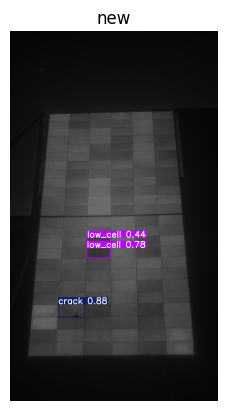

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

model = YOLO("/content/drive/MyDrive/yolo-training(new)/v8m-custom/weights/best.pt")

results = model("/content/DSC_1785 (1).JPG", conf=0.25)


res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title("new")
plt.axis('off')
plt.show()

# model = YOLO("/content/drive/MyDrive/yolo-training(old)/v8m-custom3/weights/best.pt")

# results = model("/content/47image-3-_jpg.rf.a240d6119bcb6a0139560d89daec946e.jpg", conf=0.25)


# res_plotted = results[0].plot()
# plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
# plt.title("old")
# plt.axis('off')
# plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

model = YOLO("/content/drive/MyDrive/yolo-training(new)/v8m-custom/weights/best.pt")

results = model("/content/DSC_1785 (1).JPG", conf=0.25)


res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.title("new")
plt.axis('off')
plt.show()